# GEO-BASED FRAUD DETECTION AND RISK SCORING SYSTEM USING TRANSACTION BEHAVIOR

## Problem Statement
Financial fraud in digital transactions poses a major risk to businesses and customers. Detecting fraudulent transactions is challenging, especially when fraud patterns are hidden within geographical differences, transaction behavior, and merchant interactions.
This project aims to identify fraudulent transactions by analyzing geo-location differences between customer and merchant, transaction amount patterns, and category-based behavior, and to build a risk-based decision system for effective fraud detection.

## Objective
* Understand fraud patterns using data analysis
* Identify key fraud indicators like:
  * Transaction amount patterns
  * Location differences between customer and merchant
  * Transaction categories
* Store data in MySQL for easy querying
* Build a risk scoring system to classify transactions
* Create a Power BI dashboard to monitor fraud

## Target Variable
is_fraud
* 0 → Legitimate Transaction
* 1 → Fraudulent Transaction



### 1. Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_column',None)

### 2. Load Dataset

In [2]:
fraud_data = pd.read_csv("../data/credit_card_fraud.csv")
fraud_data.head()

,category,amt,gender,state,lat,long,city_pop,merch_lat,merch_long,is_fraud
0,8.0,4.97,0.0,27.0,36.0788,-81.1781,3495.0,36.011290,-82.04832,0.0
1,4.0,107.23,0.0,47.0,48.8878,-118.2105,149.0,49.159046,-118.18646,0.0
2,0.0,220.11,1.0,13.0,42.1808,-112.2620,4154.0,43.150703,-112.15448,0.0
3,2.0,45.00,1.0,26.0,46.2306,-112.1138,1939.0,47.034332,-112.56107,0.0
4,9.0,41.96,1.0,45.0,38.4207,-79.4629,99.0,38.675000,-78.63246,0.0


In [3]:
fraud_data.shape

(1048575, 10)

In [4]:
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   category    1048575 non-null  float64
 1   amt         1048575 non-null  float64
 2   gender      1048575 non-null  float64
 3   state       1048575 non-null  float64
 4   lat         1048575 non-null  float64
 5   long        1048575 non-null  float64
 6   city_pop    1048575 non-null  float64
 7   merch_lat   1048575 non-null  float64
 8   merch_long  1048575 non-null  float64
 9   is_fraud    1048575 non-null  float64
dtypes: float64(10)
memory usage: 80.0 MB


In [5]:
fraud_data.describe()

,category,amt,gender,state,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.229184e+00,7.027910e+01,4.526209e-01,2.666967e+01,3.853336e+01,-9.022626e+01,8.905776e+04,3.853346e+01,-9.022648e+01,5.727773e-03
std,3.914008e+00,1.599518e+02,4.977504e-01,1.433080e+01,5.076852e+00,1.375858e+01,3.024351e+05,5.111233e+00,1.377093e+01,7.546503e-02
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902778e+01,-1.666712e+02,0.000000e+00
25%,3.000000e+00,9.640000e+00,0.000000e+00,1.500000e+01,3.462050e+01,-9.679800e+01,7.430000e+02,3.472954e+01,-9.689864e+01,0.000000e+00
50%,6.000000e+00,4.745000e+01,0.000000e+00,2.700000e+01,3.935430e+01,-8.747690e+01,2.456000e+03,3.936295e+01,-8.743922e+01,0.000000e+00
75%,1.000000e+01,8.305000e+01,1.000000e+00,3.800000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195602e+01,-8.023228e+01,0.000000e+00
max,1.300000e+01,2.894890e+04,1.000000e+00,5.000000e+01,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695091e+01,1.000000e+00


In [6]:
fraud_data.isnull().sum()

category      0
amt           0
gender        0
state         0
lat           0
long          0
city_pop      0
merch_lat     0
merch_long    0
is_fraud      0
dtype: int64

In [7]:
fraud_data.nunique()

category          14
amt            48602
gender             2
state             51
lat              950
long             951
city_pop         865
merch_lat     935593
merch_long    949328
is_fraud           2
dtype: int64

In [8]:
fraud_data.duplicated().sum()

0

### INITIAL OBSERVATIONS
1. The dataset contains <b>1,048,575</b> transactions with <b>10 features</b>
2. All columns have non-null values, indicating no missing data
3. No duplicate records were found
4. All variables are already in a structured and numerical format, making them analysis-ready

### 5. EDA Visualisation

In [9]:
fraud_data['is_fraud'].value_counts()
fraud_data['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0.0    99.427223
1.0     0.572777
Name: proportion, dtype: float64

### OBSERVATION: 
The dataset is <B>highly imbalanced</B>, with fraudulent transactions accounting for only <B> 0.57% </b>of total transactions,


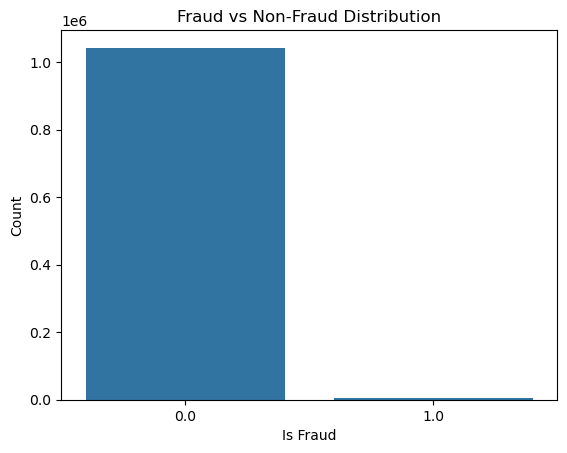

In [10]:
sns.countplot(x='is_fraud', data=fraud_data)
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

#### Insight
Fraud cases are extremely rare (imbalanced dataset)

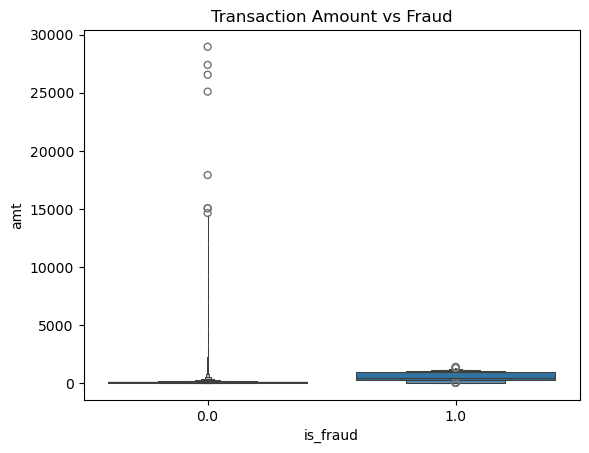

In [11]:
# Transaction Amount vs Fraud

sns.boxenplot(data = fraud_data,
              x='is_fraud', 
              y='amt')
plt.title("Transaction Amount vs Fraud")
plt.show()

#### Insight:
Fraud transactions do not always involve high amounts; instead, they tend to occur within a moderate range, indicating that fraudsters may avoid large transactions to reduce detection risk.

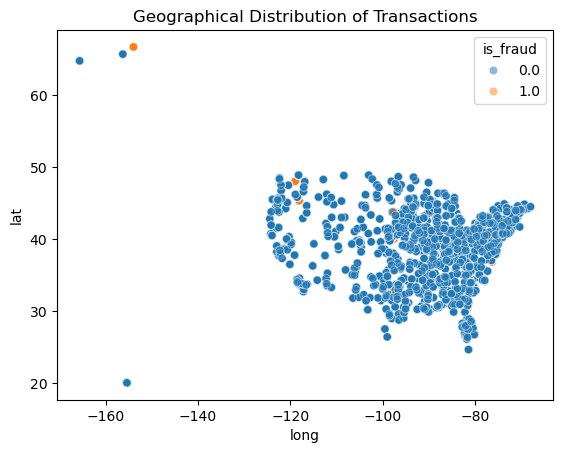

In [12]:
# Geographical Distribution

sns.scatterplot(
    x='long', y='lat',
    hue='is_fraud',
    data=fraud_data,
    alpha=0.5
)
plt.title("Geographical Distribution of Transactions")
plt.show()

#### Insight:
Fraudulent transactions are geographically dispersed and do not form clear clusters, suggesting that fraud occurs across multiple regions rather than being concentrated in a single location.

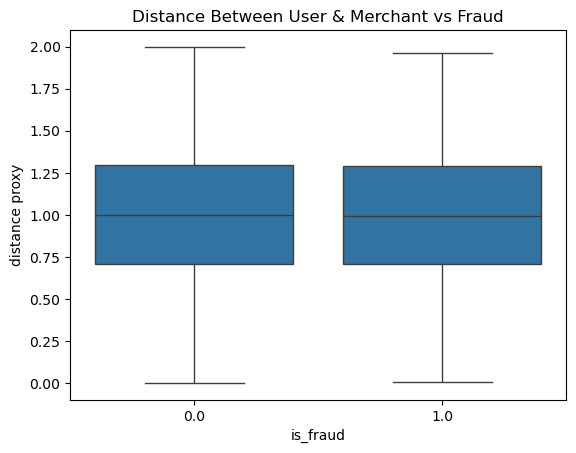

In [13]:
# Distance Proxy vs Fraud

fraud_data['distance proxy'] = (
    abs(fraud_data['lat'] - fraud_data['merch_lat']) +
    abs(fraud_data['long'] - fraud_data['merch_long'])
)
sns.boxplot(data = fraud_data, x='is_fraud', y='distance proxy')
plt.title('Distance Between User & Merchant vs Fraud')
plt.show()

#### Insight:
The distance between customer and merchant locations does not show a significant difference between fraudulent and non-fraudulent transactions based on the current proxy feature. This suggests that distance alone may not be a strong indicator of fraud in its current form.

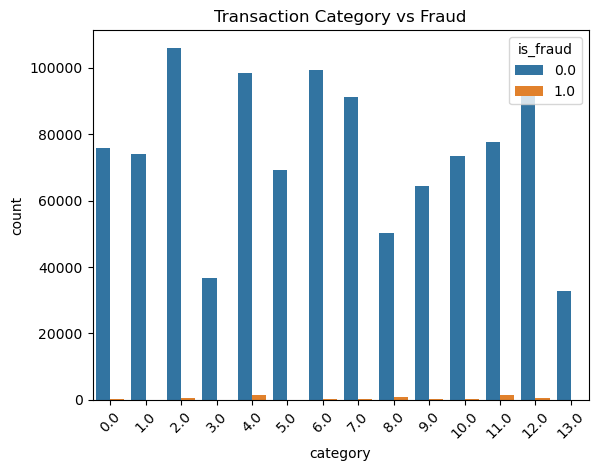

In [14]:
# Category vs Fraud

sns.countplot(x='category', hue='is_fraud', data=fraud_data)
plt.title("Transaction Category vs Fraud")
plt.xticks(rotation=45)
plt.show()

#### Insight:
Fraud occurrence varies across transaction categories, indicating that certain types of purchases are more prone to fraudulent activity.

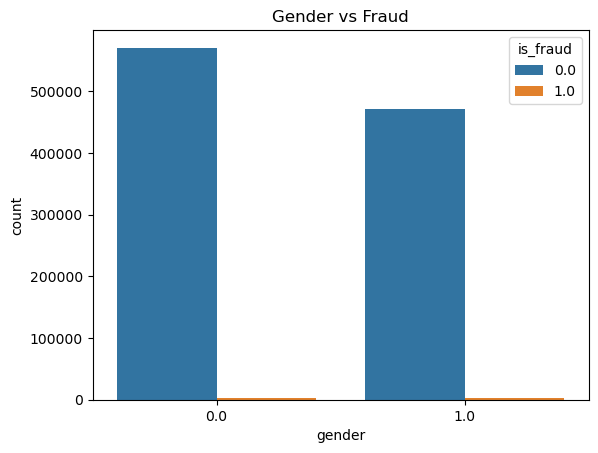

In [15]:
# Gender vs Fraud

sns.countplot(x='gender', hue='is_fraud', data=fraud_data)
plt.title("Gender vs Fraud")
plt.show()

#### Insight:
Fraud is observed across both genders with no significant variation, suggesting that gender is not a strong standalone indicator of fraudulent behavior.

### 6. Feature Engineering

#### Real Geo Distance Calculation (Haversine Formula)
Initially, a simple distance proxy was used by calculating the difference between customer and merchant coordinates. However, this method does not accurately represent real-world geographical distance.

To improve accuracy, the Haversine formula is used to calculate the actual distance (in kilometers) between two geographic points on the Earth based on their latitude and longitude.

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    # Earth radius in km
    R = 6371  
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c



In [17]:
fraud_data ['geo_distance_km'] = haversine(
    fraud_data['lat'],
    fraud_data['long'],
    fraud_data['merch_lat'],
    fraud_data['merch_long']
)

In [18]:
fraud_data['geo_distance_km']

0           78.598049
1           30.212073
2          108.205978
3           95.673308
4           77.556703
              ...    
1048570     34.507691
1048571     42.426235
1048572    135.264303
1048573    130.508931
1048574     65.111673
Name: geo_distance_km, Length: 1048575, dtype: float64

In [19]:
fraud_data['geo_distance_km'].describe()

count    1.048575e+06
mean     7.610218e+01
std      2.911262e+01
min      2.205107e-02
25%      5.533246e+01
50%      7.821088e+01
75%      9.847991e+01
max      1.521172e+02
Name: geo_distance_km, dtype: float64

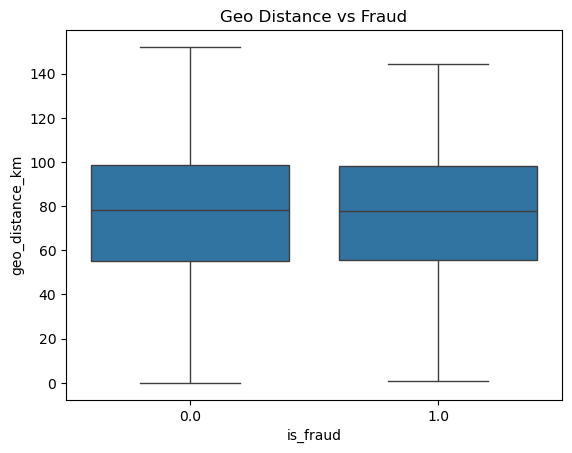

In [20]:
# Geo Distance in km vs Fraud

sns.boxplot(x='is_fraud', y='geo_distance_km', data=fraud_data)
plt.title("Geo Distance vs Fraud")
plt.show()

#### Insight 
The boxplot shows that the geographical distance between customer and merchant locations is nearly identical for both fraudulent and non-fraudulent transactions. This indicates that geo-distance does not significantly differentiate fraud and is not a strong standalone predictor.

In [21]:
# Amount deviation

fraud_data['avg_amt_category'] = fraud_data.groupby('category')['amt'].transform('mean')
fraud_data['amt_deviation'] = fraud_data['amt'] / fraud_data['avg_amt_category']


In [22]:
fraud_data['amt_deviation']

0          0.061278
1          0.916629
2          3.430606
3          0.709541
4          0.670593
             ...   
1048570    1.422435
1048571    1.868904
1048572    0.365721
1048573    0.175865
1048574    0.108836
Name: amt_deviation, Length: 1048575, dtype: float64

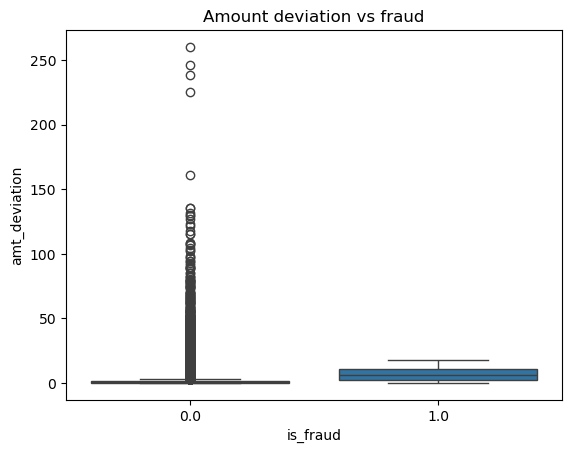

In [23]:
sns.boxplot(x='is_fraud', y='amt_deviation', data=fraud_data)
plt.title('Amount deviation vs fraud')
plt.show()

#### Insight
Fraudulent transactions tend to have higher amount deviation compared to non-fraudulent transactions, indicating that they significantly differ from the typical spending pattern within their category.

In [24]:
fraud_data['high_distance_flag'] = fraud_data['geo_distance_km'].apply(lambda x: 1 if x > 100 else 0)

In [25]:
fraud_data.groupby('high_distance_flag')['is_fraud'].mean()

high_distance_flag
0    0.005739
1    0.005690
Name: is_fraud, dtype: float64

#### Insight
The high-distance flag does not show any significant difference in fraud rates, indicating that transactions occurring at larger distances are not necessarily more fraudulent in this dataset.

In [26]:
category_risk = fraud_data.groupby('category')['is_fraud'].mean()

fraud_data['category_risk'] = fraud_data['category'].map(category_risk)

In [27]:
fraud_data.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

category
11.0    0.017427
8.0     0.014526
4.0     0.013973
12.0    0.007016
2.0     0.004679
13.0    0.003046
9.0     0.003008
3.0     0.002996
0.0     0.002435
10.0    0.002340
7.0     0.002122
1.0     0.001634
6.0     0.001536
5.0     0.001499
Name: is_fraud, dtype: float64

#### Insight
Fraud rates vary significantly across transaction categories, with certain categories exhibiting substantially higher fraud rates. This indicates that category-based behavior is a strong indicator of fraudulent activity.

<b>Category and Fraud Rate</b>
* 11 ->	1.74%
* 8	 ->  1.45%
* 4	 ->  1.39% 

### 7. Risk Score System

In [28]:
fraud_data['risk_score'] = (
    fraud_data['amt_deviation'] * 0.5 +
    fraud_data['category_risk'] * 100 * 0.4 +
    fraud_data['geo_distance_km'] * 0.1
)

In [29]:
def risk_level(score):
    if score > 80:
        return "High Risk"
    elif score > 40:
        return "Medium Risk"
    else:
        return "Low Risk"

fraud_data['risk_level'] = fraud_data['risk_score'].apply(risk_level)

In [30]:
fraud_data.groupby('risk_level')['is_fraud'].mean()

risk_level
High Risk      0.000000
Low Risk       0.005728
Medium Risk    0.000000
Name: is_fraud, dtype: float64

In [31]:
fraud_data['risk_score'].describe()

count    1.048575e+06
mean     8.339329e+00
std      3.052546e+00
min      1.252831e-01
25%      6.208474e+00
50%      8.512035e+00
75%      1.057607e+01
max      1.404205e+02
Name: risk_score, dtype: float64

#### Insight 
The initial risk classification using fixed thresholds did not effectively differentiate between fraudulent and non-fraudulent transactions, as all fraud cases were categorized under the low-risk segment. This indicates that the chosen thresholds were not aligned with the actual distribution of the risk score.

To overcome this limitation, a percentile-based thresholding approach was adopted to dynamically segment transactions into risk categories based on the distribution of the risk score.

In [32]:
# Using percentile

low_threshold = fraud_data['risk_score'].quantile(0.75)   # ~10.6
high_threshold = fraud_data['risk_score'].quantile(0.90)  # likely ~12–15

In [33]:
def risk_level(score):
    if score > high_threshold:
        return "High Risk"
    elif score > low_threshold:
        return "Medium Risk"
    else:
        return "Low Risk"

fraud_data['risk_level'] = fraud_data['risk_score'].apply(risk_level)

In [34]:
fraud_data.groupby('risk_level')['is_fraud'].mean()

risk_level
High Risk      0.023451
Low Risk       0.003319
Medium Risk    0.005957
Name: is_fraud, dtype: float64

#### Insight
The percentile-based risk classification successfully differentiated fraudulent transactions, with the high-risk segment showing the highest fraud rate, followed by medium and low-risk segments. This confirms that the risk scoring system is effective in identifying suspicious transactions.

In [35]:
fraud_data.to_csv("final_fraud_data.csv", index=False)

In [36]:
fraud_data.head(5)

,category,amt,gender,state,lat,long,city_pop,merch_lat,merch_long,is_fraud,distance proxy,geo_distance_km,avg_amt_category,amt_deviation,high_distance_flag,category_risk,risk_score,risk_level
0,8.0,4.97,0.0,27.0,36.0788,-81.1781,3495.0,36.011290,-82.04832,0.0,0.937730,78.598049,81.105671,0.061278,0,0.014526,8.471471,Low Risk
1,4.0,107.23,0.0,47.0,48.8878,-118.2105,149.0,49.159046,-118.18646,0.0,0.295286,30.212073,116.983042,0.916629,0,0.013973,4.038447,Low Risk
2,0.0,220.11,1.0,13.0,42.1808,-112.2620,4154.0,43.150703,-112.15448,0.0,1.077423,108.205978,64.160673,3.430606,1,0.002435,12.633294,High Risk
3,2.0,45.00,1.0,26.0,46.2306,-112.1138,1939.0,47.034332,-112.56107,0.0,1.251002,95.673308,63.421290,0.709541,0,0.004679,10.109266,Low Risk
4,9.0,41.96,1.0,45.0,38.4207,-79.4629,99.0,38.675000,-78.63246,0.0,1.084740,77.556703,62.571442,0.670593,0,0.003008,8.211292,Low Risk


In [37]:
fraud_data.rename(columns={'long': 'longitude'}, inplace=True)
fraud_data.to_csv("final_fraud_data.csv", index=False)

In [38]:
fraud_data.head(5)

,category,amt,gender,state,lat,longitude,city_pop,merch_lat,merch_long,is_fraud,distance proxy,geo_distance_km,avg_amt_category,amt_deviation,high_distance_flag,category_risk,risk_score,risk_level
0,8.0,4.97,0.0,27.0,36.0788,-81.1781,3495.0,36.011290,-82.04832,0.0,0.937730,78.598049,81.105671,0.061278,0,0.014526,8.471471,Low Risk
1,4.0,107.23,0.0,47.0,48.8878,-118.2105,149.0,49.159046,-118.18646,0.0,0.295286,30.212073,116.983042,0.916629,0,0.013973,4.038447,Low Risk
2,0.0,220.11,1.0,13.0,42.1808,-112.2620,4154.0,43.150703,-112.15448,0.0,1.077423,108.205978,64.160673,3.430606,1,0.002435,12.633294,High Risk
3,2.0,45.00,1.0,26.0,46.2306,-112.1138,1939.0,47.034332,-112.56107,0.0,1.251002,95.673308,63.421290,0.709541,0,0.004679,10.109266,Low Risk
4,9.0,41.96,1.0,45.0,38.4207,-79.4629,99.0,38.675000,-78.63246,0.0,1.084740,77.556703,62.571442,0.670593,0,0.003008,8.211292,Low Risk


In [39]:
fraud_data.duplicated().sum()

0

In [40]:
print(fraud_data.columns)

Index(['category', 'amt', 'gender', 'state', 'lat', 'longitude', 'city_pop',
       'merch_lat', 'merch_long', 'is_fraud', 'distance proxy',
       'geo_distance_km', 'avg_amt_category', 'amt_deviation',
       'high_distance_flag', 'category_risk', 'risk_score', 'risk_level'],
      dtype='object')


In [41]:
fraud_data_clean = fraud_data[[
    'category',
    'amt',
    'gender',
    'state',
    'lat',
    'longitude',
    'merch_lat',
    'merch_long',
    'is_fraud',
    'geo_distance_km',
    'amt_deviation',
    'category_risk',
    'risk_score',
    'risk_level'
]]

In [42]:
fraud_data_clean.to_csv("final_fraud_data.csv", index=False)

In [43]:
fraud_data_clean.sample(200000).to_csv("sample_fraud_data.csv", index=False)

### 8. SQL

In [44]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [45]:
import mysql.connector

conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'root',
    database = "fraud_detection_project"
)
cursor = conn.cursor()

In [46]:
for _, row in fraud_data_clean.iterrows():
    cursor.execute("""
        INSERT INTO fraud_transactions (
            category, amt, gender, state, lat, longitude,
            merch_lat, merch_long, is_fraud,
            geo_distance_km, amt_deviation,
            category_risk, risk_score, risk_level
        )
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, tuple(row))

conn.commit()

### -> 1. OVERALL FRAUD RATE

In [47]:
# SQL Query used in MySQL Workbench

query = """ """

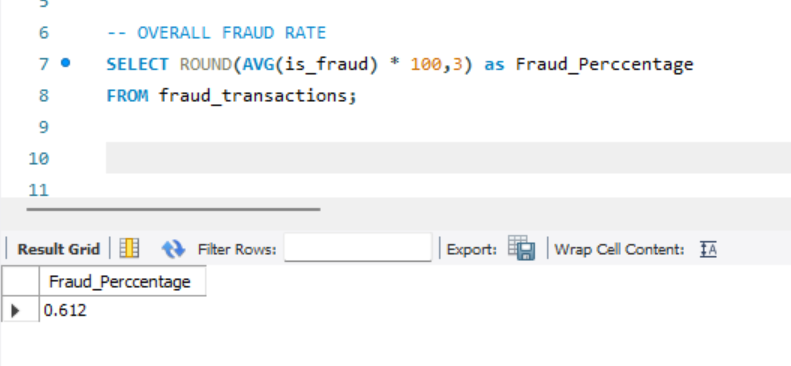

#### Insight
The overall fraud rate is **~0.61%**, indicating a highly imbalanced dataset. 
This reflects real-world fraud detection scenarios where fraudulent transactions are rare but have high business impact, making accurate risk identification critical.

### -> 2. RISK LEVEL PERFORMANCE

In [48]:
# SQL Query used in MySQL Workbench

query = """ """

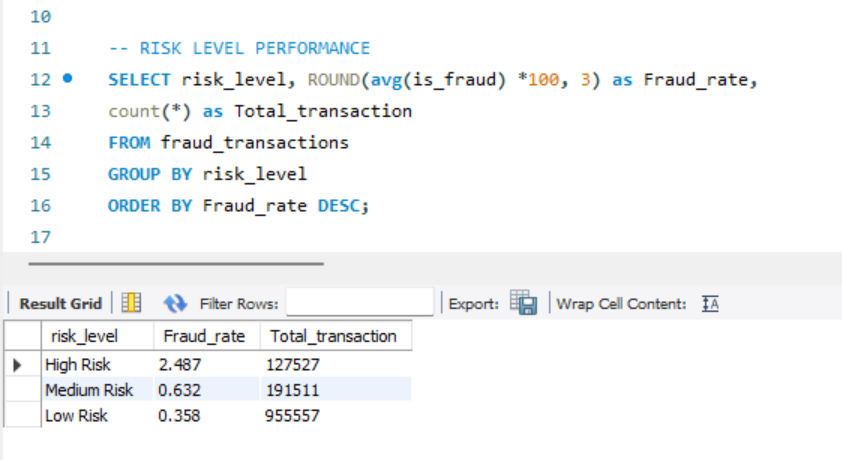

#### Insight
Fraud rate increases significantly as risk level increases. High-risk transactions show the highest fraud probability, validating that the rule-based risk scoring system is effectively segmenting risky transactions.


### -> 3. RISK SCORE VALIDATION

In [55]:
# SQL Query used in MySQL Workbench

query = """ """

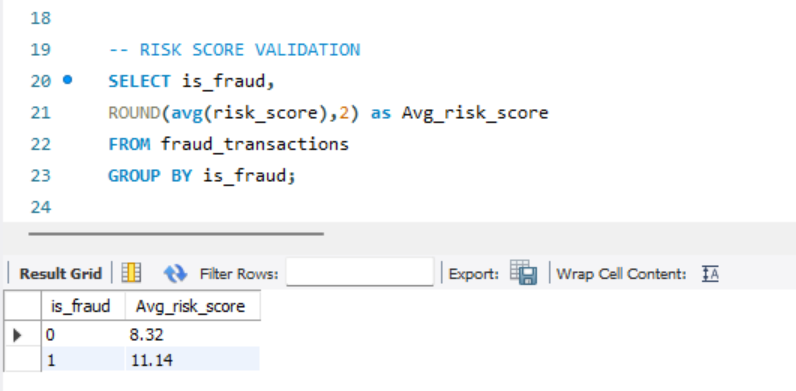

#### Insight
Fraudulent transactions have a higher average risk score compared to non-fraud transactions, confirming that the scoring model successfully captures risky behavior patterns.


### -> 4. CATEGORY ANALYSIS

In [51]:
# SQL Query used in MySQL Workbench

query = """ """

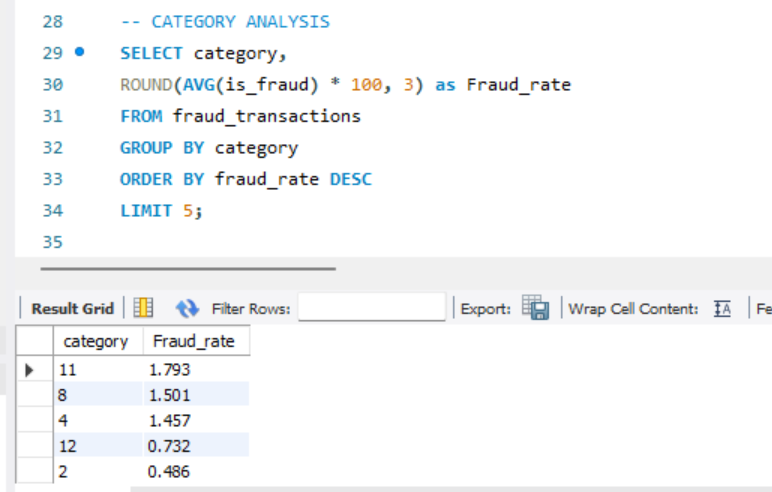

#### Insight
Certain transaction categories exhibit higher fraud rates, indicating that fraud is more concentrated in specific types of spending behavior. These categories can be prioritized for stricter monitoring.

### -> 5. RISK DISTRIBUTION

In [52]:
# SQL Query used in MySQL Workbench

query = """ """

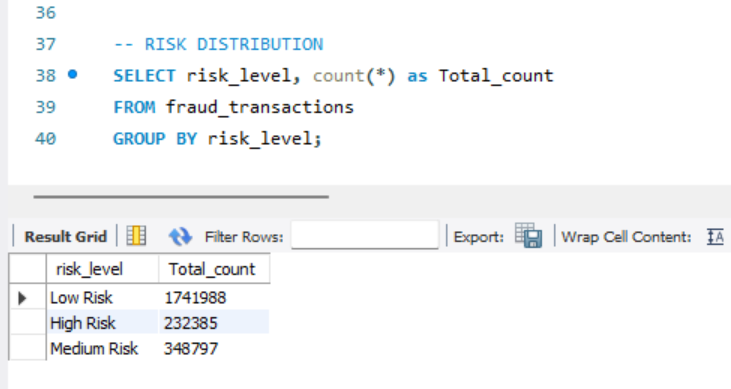

#### Insight
The majority of transactions fall under the low-risk category, while high-risk transactions are fewer but contribute disproportionately to fraud cases, highlighting the importance of targeted risk filtering.

### -> 6. GEO INSIGHT

In [54]:
# SQL Query used in MySQL Workbench

query = """ """

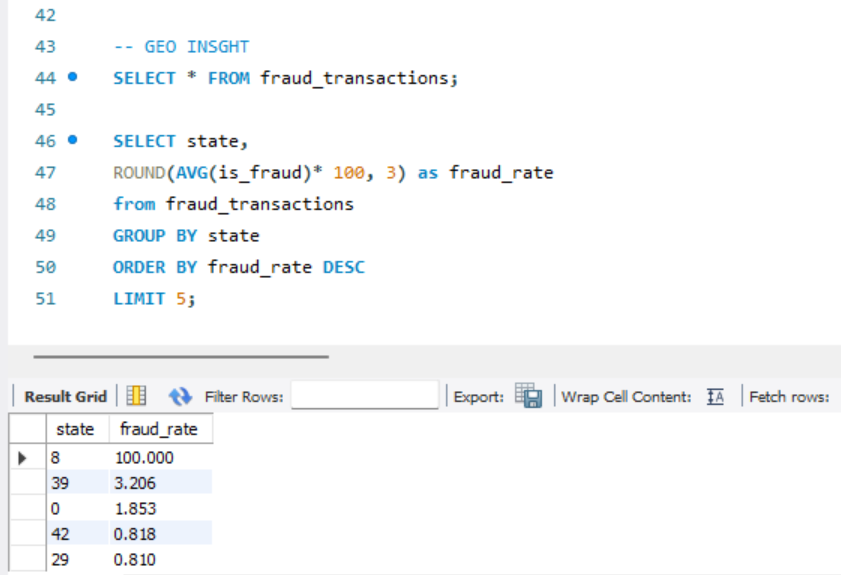

#### Insight
Fraud rates vary across different states, suggesting that geographical factors influence fraud occurrence. This supports the use of geo-based features in fraud detection systems.

### SQL FINAL INSIGHT 
* The SQL analysis confirms that fraud is highly concentrated in specific risk segments, categories, and geographic regions.
* The risk scoring system effectively differentiates fraudulent transactions, making it a reliable foundation for real-time fraud detection and decision-making systems.